In [ ]:
pip install -U transformers accelerate peft trl datasets bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 992.6/992.6 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 80.7 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transforme

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
tokenizer=AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM2-360M")



config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.66k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/801k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/831 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.10M [00:00<?, ?B/s]

Testing a simple example

In [ ]:
example={"problem": "The theft of 'The Azure Serpent,' a priceless masterpiece, from Lord Ashworth's private gallery has baffled the constabulary. The gallery, a single room on the ground floor, was secured by a heavy oak door and barred windows, all locked from the *inside*. The state-of-the-art alarm system, which included pressure plates, laser grids, and motion sensors, was fully armed and showed no sign of tampering or activation. Mr. Jones, the night watchman, was discovered unconscious outside the gallery door at 6 AM, suffering from a blow to the head. He remembers nothing after his 2 AM rounds. Forensic examination confirmed no forced entry to the gallery door or windows. The only peculiarity found *inside* the gallery was a single, small, distinct muddy boot print, size 6, near a rarely-used maintenance access panel for the ventilation system, located at floor level. There were no other muddy prints inside the gallery or leading to the gallery from the outside. The painting itself, a canvas measuring 6 by 4 feet, was too large to fit through the ventilation shaft. The night of the theft was marked by an exceptionally violent storm, with torrential rain and high winds from midnight until dawn. The maid, Mrs. Gable, reported hearing a loud 'thump' from the direction of the gallery at approximately 2:15 AM, which she attributed to the storm.", "observations": ["The priceless painting 'The Azure Serpent' was stolen from Lord Ashworth's private gallery.", "The gallery's heavy oak door and barred windows were locked from the inside.", "The state-of-the-art alarm system was fully armed and showed no sign of tampering or activation.", "Mr. Jones, the night watchman, was found unconscious outside the gallery door at 6 AM with a blow to the head.", "Mr. Jones remembers nothing after his 2 AM rounds.", "Forensic examination confirmed no forced entry to the gallery door or windows.", "A single, small, distinct muddy boot print, size 6, was found inside the gallery near a maintenance access panel for the ventilation system.", "No other muddy prints were found inside the gallery or leading to the gallery from the outside.", "The painting measures 6 by 4 feet and is too large to fit through the ventilation shaft.", "The night of the theft (midnight until dawn) experienced an exceptionally violent storm with torrential rain and high winds.", "Mrs. Gable, the maid, heard a loud 'thump' from the direction of the gallery at approximately 2:15 AM, which she attributed to the storm."], "possible_scenario": ["A small individual gained entry through the ventilation system, opened the main door for an accomplice to remove the painting, and then locked the door from the inside before exiting through the ventilation system.", "Mr. Jones, the night watchman, was involved in the theft, possibly with an accomplice, and staged his own injury.", "The thief was already concealed within the gallery before it was locked for the night, then stole the painting and incapacitated Mr. Jones upon exiting."], "impossible_scenario": [{"scenario": "A single thief entered through the main door, stole the painting, and then locked the door from the inside before escaping.", "reason": "It is physically impossible for a single individual to lock a standard door from the inside and then exit through that same locked door."}, {"scenario": "The painting was stolen by a single person who entered and exited via the ventilation system.", "reason": "The painting measures 6 by 4 feet, and the problem explicitly states it was 'too large to fit through the ventilation shaft'."}, {"scenario": "Mr. Jones, the night watchman, was the sole perpetrator of the theft.", "reason": "The discovery of a single, small, muddy boot print (size 6) inside the gallery, near the ventilation panel, with no other muddy prints, strongly suggests the presence of a second, smaller individual who entered via a non-standard route, which contradicts the idea of Jones acting alone."}, {"scenario": "The thief (or thieves) gained entry through the main door or windows by force.", "reason": "Forensic examination confirmed 'no forced entry to the gallery door or windows,' and the 'state-of-the-art alarm system... showed no sign of tampering or activation'."}], "deduction": "Watson, the facts, when meticulously observed, weave a tapestry far more intricate than the constabulary's crude assumptions. We are presented with a locked-room mystery: a priceless painting vanishes, yet the room's formidable door and barred windows remain locked from within, devoid of any forced entry. Furthermore, the sophisticated alarm system, a veritable spiderweb of sensors, was entirely undisturbed. This immediately rules out any conventional break-in by force. The notion of a single thief entering through the main door, committing the theft, and then somehow locking the door from the inside before vanishing into thin air is patently absurd; one cannot lock a door from the inside and then exit through it. Similarly, the idea that the thief simply spirited the massive 'Azure Serpent' through the narrow ventilation shaft is dismissed by the painting's very dimensions – six by four feet, a formidable canvas indeed. Then we consider Mr. Jones, the unconscious watchman. His incapacitation at 2 AM, coupled with his convenient amnesia, might tempt one to suspect complicity. However, the presence of that solitary, small, muddy boot print – size 6, mind you – found deep within the gallery, near the ventilation access, is a formidable obstacle to such a theory. If Jones were the sole perpetrator, or even working with an accomplice using the main door, why would this singular, small, muddy print appear, without any corresponding track leading to it? It speaks not of a direct entry via the door, nor of Jones's larger frame. The truly perplexing clue is this isolated muddy print. The violent storm that raged all night provides the perfect context for mud. No other muddy prints suggests a very specific, limited point of entry and exit. The print's small size, coupled with its location near the ventilation panel, strongly indicates that a diminutive individual entered *through the ventilation system*. This individual, however, could not have transported the immense painting themselves. Their purpose, therefore, must have been to facilitate the entry or exit of the painting via the main door. The sequence of events becomes clear: A small accomplice, agile enough to navigate the ventilation shafts, entered the gallery around 2:15 AM – coincidentally, the time Mrs. Gable heard the 'thump,' likely the sound of the small individual dropping or repositioning something upon entry. This small individual then unlocked the main gallery door from the *inside*. An accomplice, or perhaps the 'mastermind,' then entered, incapacitated Mr. Jones who was making his rounds (explaining his 2 AM memory cutoff and his location outside the door), and removed the painting. The small accomplice, still inside, could then lock the main door from the *inside* once the painting and the larger thief had departed, before making their own exit back through the ventilation system, leaving only that single, tell-tale muddy print as their fleeting signature. This explains the 'locked from inside' paradox, the absence of alarm triggers, the painting's size, and the peculiar boot print, all while accounting for Jones's injury.", "final_answer": "The theft was an elaborate two-person operation. A small accomplice entered through the ventilation system, unlocked the main door from the inside for a larger thief to remove the painting and incapacitate Mr. Jones, and then locked the door from the inside before exiting through the ventilation shaft.", "context": "crime/mystery scenario", "difficulty": 5}
words=''
for key in example:
  if key=='context':
    continue
  if key=='difficulty':
    continue
  words+=key
  words+=': '
  if isinstance(example[key],list):
    for elements in example[key]:
      if isinstance(elements, dict):
        for subkey in elements:
          words+=subkey
          words+=': '
          words+=elements[subkey]
          words+='\n '
      else:
        words+=elements
        words+='\n '
  elif isinstance(example[key],dict):
    for subkey in example[key]:
      words+=subkey
      words+=': '
      words+=example[key][subkey]
      words+='\n '
  else:
    words+=example[key]
    words+='\n '
words

"problem: The theft of 'The Azure Serpent,' a priceless masterpiece, from Lord Ashworth's private gallery has baffled the constabulary. The gallery, a single room on the ground floor, was secured by a heavy oak door and barred windows, all locked from the *inside*. The state-of-the-art alarm system, which included pressure plates, laser grids, and motion sensors, was fully armed and showed no sign of tampering or activation. Mr. Jones, the night watchman, was discovered unconscious outside the gallery door at 6 AM, suffering from a blow to the head. He remembers nothing after his 2 AM rounds. Forensic examination confirmed no forced entry to the gallery door or windows. The only peculiarity found *inside* the gallery was a single, small, distinct muddy boot print, size 6, near a rarely-used maintenance access panel for the ventilation system, located at floor level. There were no other muddy prints inside the gallery or leading to the gallery from the outside. The painting itself, a ca

In [ ]:
Analysing a single dataset

In [ ]:
words_list=words.split()
word_count=len(words_list)
token_list=tokenizer.tokenize(words)
token_count=len(token_list)
print(f'Word count: {word_count}')
print(f'Token count: {token_count}')

Word count: 1218
Token count: 1601


**Analyse the whole dataset**

In [ ]:
import json
import pandas as pd

def flatten_example(example):
  words=''
  for key in example:
    if key=='context':
      continue
    if key=='difficulty':
      continue
    words+=key
    words+=': '
    if isinstance(example[key],list):
      for elements in example[key]:
        if isinstance(elements, dict):
          for subkey in elements:
            words+=subkey
            words+=': '
            words+=elements[subkey]
            words+='\n '
        else:
          words+=elements
          words+='\n '
    elif isinstance(example[key],dict):
      for subkey in example[key]:
        words+=subkey
        words+=': '
        words+=example[key][subkey]
        words+='\n '
    else:
      words+=example[key]
      words+='\n '
  return words

records = []
dataset='/content/drive/MyDrive/dataset_for_SMOLLM/dataset.jsonl'
with open(dataset, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        line = line.strip()
        if not line:
            continue
        try:
            example = json.loads(line)
        except json.JSONDecodeError as e:
            print(f"Line {i} failed to parse: {e}")
            continue

        flat = flatten_example(example)
        word_count = len(flat.split())
        token_count = len(tokenizer.tokenize(flat))

        records.append({
            "idx": i,
            "difficulty": example.get("difficulty"),
            "context": example.get("context"),
            "word_count": word_count,
            "token_count": token_count,
        })

df = pd.DataFrame(records)
df


,idx,difficulty,context,word_count,token_count
0,0,1,crime/mystery scenario,208,283
1,1,2,crime/mystery scenario,477,606
2,2,3,crime/mystery scenario,511,731
3,3,4,crime/mystery scenario,569,822
4,4,5,crime/mystery scenario,661,929
...,...,...,...,...,...
981,981,4,pure information/facts,735,1021
982,982,5,pure information/facts,560,789
983,983,1,crime/mystery scenario,372,473
984,984,2,crime/mystery scenario,642,849


In [ ]:
print(f"Total examples loaded: {len(df)}")
df.describe()

Total examples loaded: 986


,idx,difficulty,word_count,token_count
count,986.000000,986.000000,986.000000,986.000000
mean,492.500000,3.026369,417.587221,580.591278
std,284.777984,1.403156,172.169604,237.783274
min,0.000000,1.000000,82.000000,150.000000
25%,246.250000,2.000000,286.000000,397.250000
50%,492.500000,3.000000,397.000000,551.000000
75%,738.750000,4.000000,517.000000,727.250000
max,985.000000,5.000000,1223.000000,1658.000000


In [ ]:
def iqr_outliers(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - k*iqr, q3 + k*iqr
    return series[(series < lower) | (series > upper)], lower, upper

token_outliers, low, high = iqr_outliers(df["token_count"])
print(f"IQR bounds: [{low:.0f}, {high:.0f}]")
print(f"{len(token_outliers)} outliers out of {len(df)} ({100*len(token_outliers)/len(df):.1f}%)")

outlier_rows = df.loc[token_outliers.index].sort_values("token_count")
outlier_rows

IQR bounds: [-98, 1222]
10 outliers out of 986 (1.0%)


,idx,difficulty,context,word_count,token_count
816,816,5,pure information/facts,918,1235
157,157,5,scientific reasoning,846,1310
608,608,5,pure information/facts,953,1331
368,368,5,pure information/facts,990,1365
204,204,5,everyday logical reasoning,936,1376
23,23,5,crime/mystery scenario,911,1393
846,846,5,everyday logical reasoning,1063,1393
921,921,4,pure information/facts,986,1400
947,947,5,crime/mystery scenario,1218,1601
318,318,5,everyday logical reasoning,1223,1658


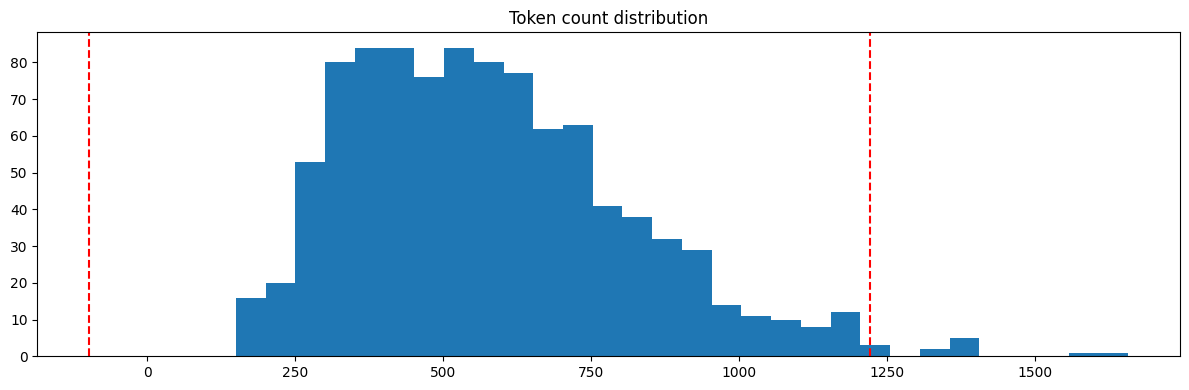

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 1, figsize=(12, 4))
axes.hist(df["token_count"], bins=30)
axes.set_title("Token count distribution")
axes.axvline(low, color='r', linestyle='--')
axes.axvline(high, color='r', linestyle='--')

plt.tight_layout()
plt.show()

Remove outliers and save the filtered dataset so as to reduce gpu load

In [ ]:
keep_df=df[df['token_count']<=1222]
keep_ids=set(keep_df['idx'])
content=''
new_file='/content/drive/MyDrive/dataset_for_SMOLLM/dataset_filtered.jsonl'
with open(dataset, "r", encoding="utf-8") as f:
  for i, line in enumerate(f):
    if i not in keep_ids:
      continue
    line = line.strip()
    content+=line
    content += '\n'
with open(new_file,'w',encoding='utf-8') as w:
  w.write(content)